# Demo: DESI Legacy Stacked PSF

In [ ]:
import sys
import os, numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits, ascii
from astropy.table import Table
from astropy.visualization import simple_norm
from IPython.display import Image, display
sys.path.append("/home/yangxinlai/Software/GalfitX-main")
from psf_tools import (select_valid_stars,subtract_background,plot_background,plot_segment,cutout_stars,build_stacked_psf,gaia_crossmatch)
from galfitx.source_detection import SExtractor
%matplotlib inline
print("Ready.")

/usr/local/anaconda3/envs/gs2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready.


## Step 1: Configuration
Here we briefly introduce the overview of the pipeline:

1. We use SExtractor to get the catalog and segment data for subsequent stacked PSF.
2. We select valid stars by motphology criteria and check whether the cutouts are fully within the image.
3. We build stacked PSF by the selected stars cutouts.

Next we will explain the pipeline more extensively with example and plot.

In [ ]:
DATA_DIR = "./"
SCI_IMAGE = os.path.join(DATA_DIR, f"image_r.fits")              # Image file for SExtractor and stacked PSF.
WHT_FILE = os.path.join(DATA_DIR, f"wht_r.fits")                # Weight file for SExtractor.
SEX_DIR = os.path.join(DATA_DIR, f"SEx")                        # Output dir for SExtractor.
CATALOG_FILE = os.path.join(SEX_DIR, "sex_out.cat")       # Catalog file result from SExtractor.
SEG_FILE = os.path.join(SEX_DIR, "sex_out_seg.fits")      # Segment file result from SExtractor.
EXT_MASK = os.path.join(DATA_DIR, "background_model.fits")       # Source mask for subtracting background (if required).
OUTPUT_DIR = os.path.join(DATA_DIR, "output")                    # Output dir for results.
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Morphology criteria parameter
COMBINED_FLAGS_LIMIT = 1    # Select stars with combined flags = 0. If change to 2, then we'll select stars with flags = 0 / 1.
ELONG_LIMIT = 1.2           # Select stars with elongation < 1.2.
CLASS_STAR_LIMIT = 0.9      # Select stars with class_star > 0.9.
MAG_BRIGHT = 17.0           # Select stars with mag > 17.0.
MAG_FAINT = 22.0            # Select stars with mag < 22.0.
SNR_LIMIT = 100.0           # Select stars with SNR > 100.
print(f"Morphology criteria: elong<{ELONG_LIMIT}, class_star>{CLASS_STAR_LIMIT}, mag {MAG_BRIGHT}-{MAG_FAINT}, SNR>{SNR_LIMIT}")

# SExtractor parameter.
DETECT_THRESH = 1.0
DETECT_MINAREA = 3          # Parameter for detect sources.
BACK_SIZE = 32
DEBLEND_NTHRESH = 32
DEBLEND_MINCONT = 0.001     # Parameter for delending.
print(f"SExtractor parameter: detect thresh={DETECT_THRESH}, detect minarea={DETECT_MINAREA}, back size={BACK_SIZE}, deblend nthresh={DEBLEND_NTHRESH}, deblend mincont={DEBLEND_MINCONT}")

Criteria: elong<1.2, class_star>0.9, mag 17.0-22.0, SNR>100.0


## Step 2: Background Subtraction

In [ ]:
sci_orig = fits.getdata(SCI_IMAGE)
sci_sub,bkg_model,bkg_rms,source_mask = subtract_background(SCI_IMAGE,
                                                            EXT_MASK,
                                                            OUTPUT_DIR,
                                                            bkg_box_size=64,
                                                            bkg_filter_size=(3,3))
plot_background(sci_orig,bkg_model,sci_sub,source_mask,OUTPUT_DIR,band='r')
hdr = fits.getheader(SCI_IMAGE)
SCI_SUB_IMAGE = os.path.join(OUTPUT_DIR, f"sci_subtracted.fits")
fits.writeto(SCI_SUB_IMAGE, sci_sub, hdr, overwrite=True)
display(Image(os.path.join(OUTPUT_DIR,"background_subtraction.png")))

## Step 3: Detect sources with SExtractor

In [ ]:
catalog, segm, src_cat = SExtractor(
            filename=SCI_SUB_IMAGE,
            catalog_name=CATALOG_FILE,
            detect_minarea=DETECT_MINAREA,
            detect_thresh=DETECT_THRESH,
            deblend=True,
            deblend_nthresh=DEBLEND_NTHRESH,
            deblend_mincont=DEBLEND_MINCONT,
            clean=True,
            back_type=True,
            back_size=BACK_SIZE,
            back_filtersize=3,
            weight_type='MAP_WEIGHT',
            weight_name=WHT_FILE,
            mag_zeropoint=22.5,
            pixel_scale=0.262,
            fwhm_arcsec=1.0,        # This parameter depends on your input image, and it affects the output class star results.
            verbose=True,           # For ground-base telescope, we can chose 1.0.
        )
seg_path = SEG_FILE
hdr = fits.getheader(SCI_IMAGE)
seg_data = segm.data.astype(np.int32)
fits.writeto(seg_path, seg_data, hdr, overwrite=True)
print(f"    Segmentation saved to {seg_path}")
plot_segment(seg_path, output_dir=OUTPUT_DIR)
display(Image(os.path.join(OUTPUT_DIR,"segment_plot.png")))

## Step 4: select_valid_stars() — SEx catalog
Here we select the stars that satisfy the criteria.

In [ ]:
selected = select_valid_stars(
                CATALOG_FILE,
                seg_file=SEG_FILE,
                elongation_limit=ELONG_LIMIT,
                class_star_limit=CLASS_STAR_LIMIT,
                combined_flags_limit=COMBINED_FLAGS_LIMIT,
                mag_bright_limit=MAG_BRIGHT,
                mag_faint_limit=MAG_FAINT,
                SNR_limit=SNR_LIMIT,
                cutout_size=63,                     # We select the stars whose cutouts are fully within the image.
                skip_bright_neighbors=True,         # If true, skip the stars with bright neighbors in the cutout.
                mag_gap_limit=3.0,
                verbose=False)                      # Suppress per-star skip messages for cleaner output.
valid_ids = [int(x) for x in selected['label']]
print(f"Satisfy morphology criteria: {len(valid_ids)}")

## Step 5: Cutout Stars

In [5]:
cut_valid_ids,sci_cuts,mask_list,valid_coords = cutout_stars(
                                sci_image=sci_sub,
                                seg_file=SEG_FILE,
                                catalog_file=CATALOG_FILE,
                                star_ids=valid_ids,
                                output_dir=OUTPUT_DIR,
                                cutout_size=63,
                                save_cutouts=True)
print(f"Cutout: {len(cut_valid_ids)} stamps")

72 out of 72 stars are fully within the image and have been cut out.
Cropped star images saved to cutouts/
Cutout: 72 stamps


## Step 6: Build Stacked PSF (basic selection)

In [ ]:
psf_basic = build_stacked_psf(
                        sci_image=SCI_SUB_IMAGE,            # We use the bkg_subtracted image.
                        catalog_file=CATALOG_FILE,
                        seg_file=SEG_FILE,
                        output_dir=OUTPUT_DIR,
                        elongation_limit=ELONG_LIMIT,
                        class_star_limit=CLASS_STAR_LIMIT,
                        combined_flags_limit=COMBINED_FLAGS_LIMIT,
                        mag_bright_limit=MAG_BRIGHT,
                        mag_faint_limit=MAG_FAINT,
                        SNR_limit=SNR_LIMIT,
                        cutout_size=63,
                        oversampling=3,
                        save_cutouts=False,
                        select_ids=valid_ids,               # We input the selected ids obtained from above,
                        pixel_scale=0.262,                  # and in build_stacked_psf, we still select stars from input ids with select_valid_ids().
                        plot_stars_image=True,
                        plot_stars_scatter=True,
                        plot_stars_radial_profile=True,
                        plot_psf_image=True,
                        )
print(f"PSF: {psf_basic}")

Input select ids are not None, select valid stars from input ids subsequently.
72 sources satisfy stellar criteria (elong<1.2, class_star>0.9, mag 17.0-22.0, SNR>100.0)


72 out of 72 stars are fully within the image and have been cut out.
Stars image saved to ./output/selected_stars_image.png
Stars scatter saved to ./output/stars_scatter.png
Radial profile plot saved to ./output/stars_radial_profiles.png
PSF image saved to ./output/stacked_psf.png
Combined 5 plots into ./output/results.pdf
PSF: ./output/psf.fits


## Step 7: Basic Results

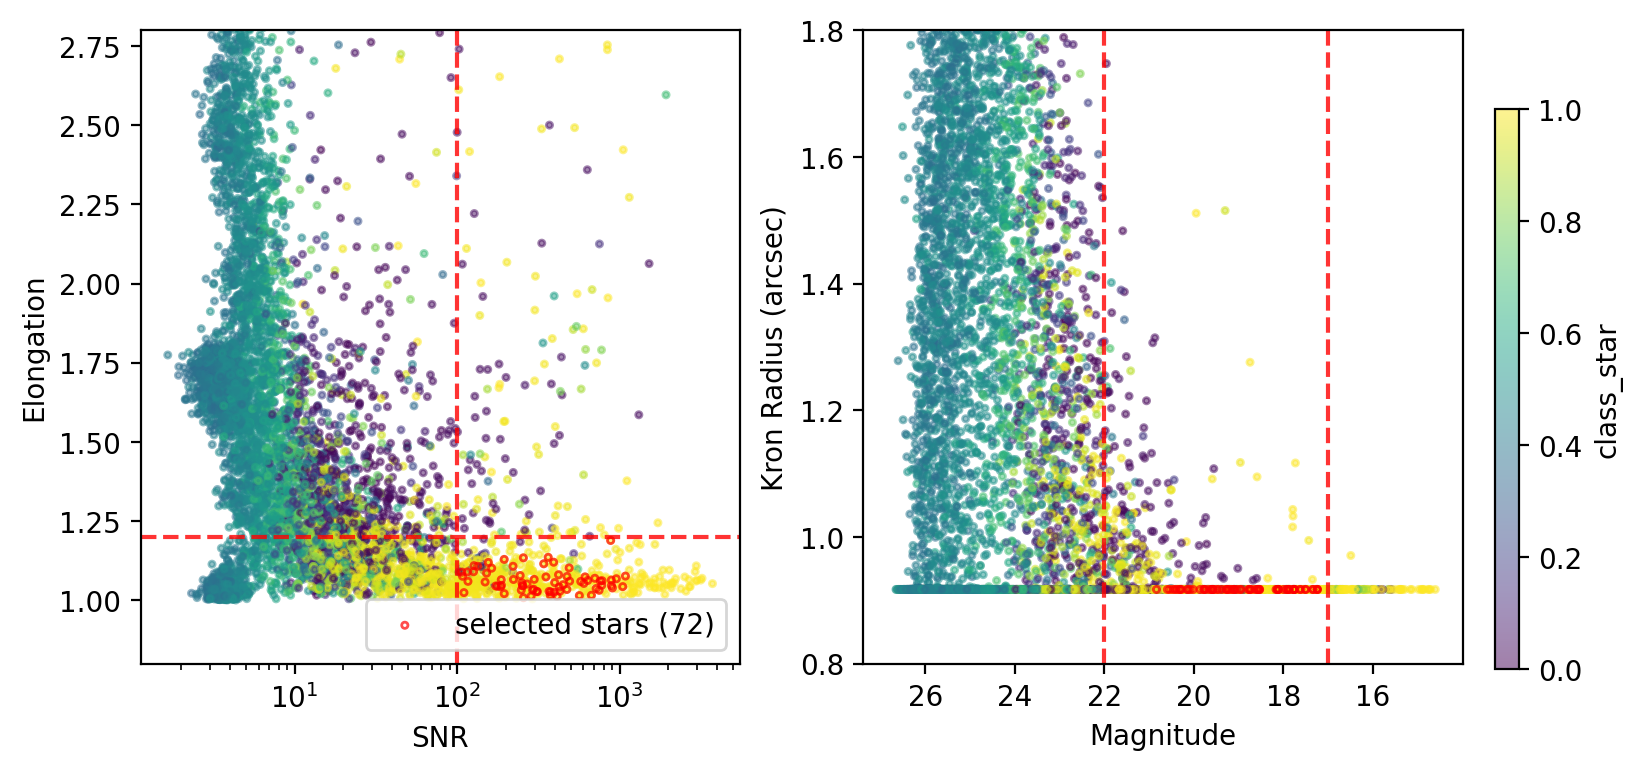

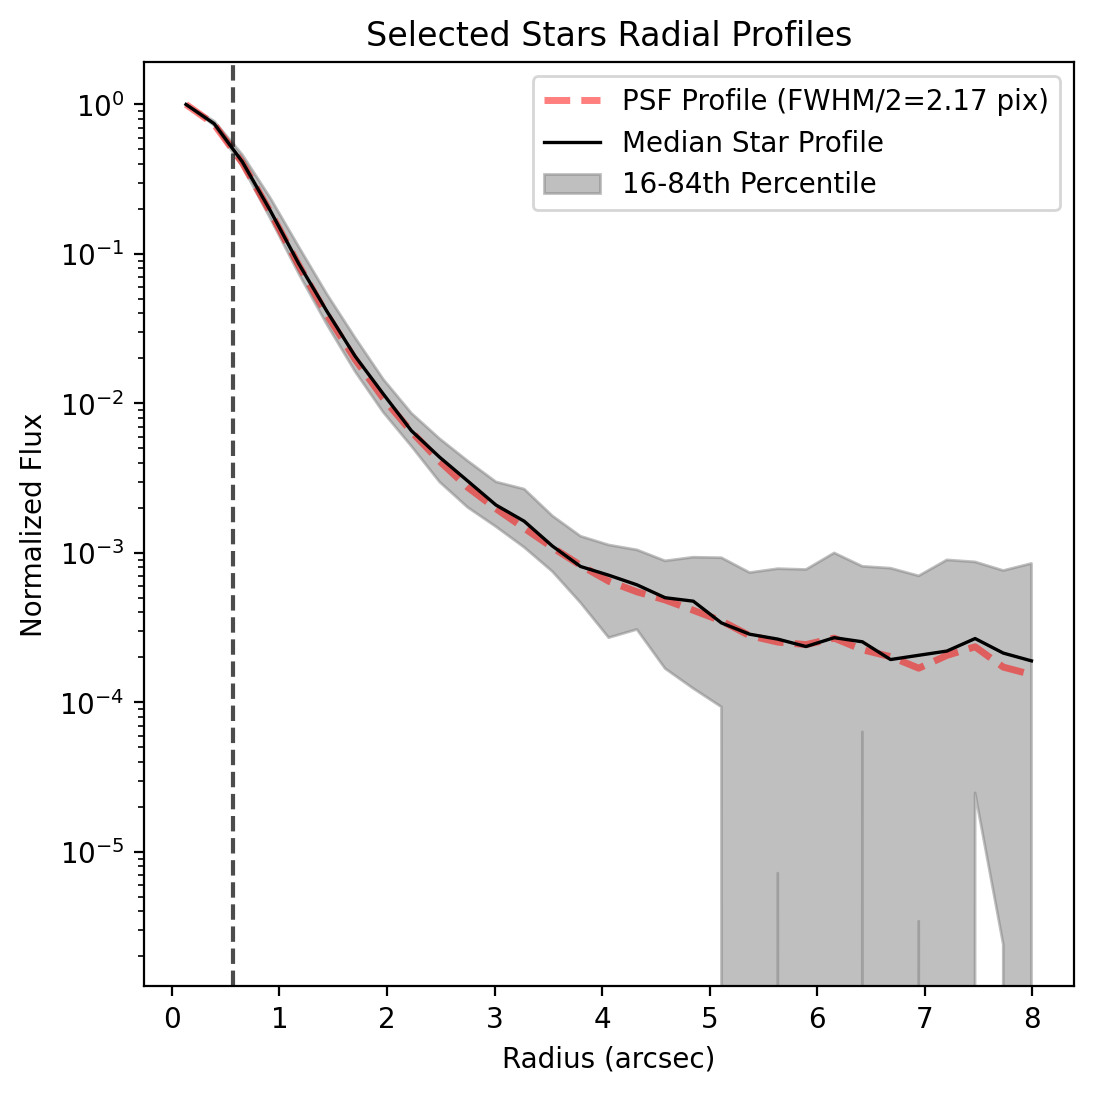

In [7]:
display(Image(os.path.join(OUTPUT_DIR,"selected_stars_image.png")))
display(Image(os.path.join(OUTPUT_DIR,"stars_scatter.png")))
display(Image(os.path.join(OUTPUT_DIR,"stars_radial_profiles.png")))

## Step 8: Gaia Crossmatch + Plx Filter
For DESI Legacy survey, we can cross match the catalog with Gaia and select stars with plx criteria.

In [ ]:
PLX_SNR = 3.0                                                       # We select stars with Gaia Plx SNR > 3.0.
gaia_raw = gaia_crossmatch(CATALOG_FILE, max_distance=0.5)
gaia_plx = gaia_raw[gaia_raw["Plx"]/gaia_raw["e_Plx"]>PLX_SNR].copy()
print(f"After Plx/e_Plx > {PLX_SNR}: {len(gaia_plx)} sources")
plx_file = os.path.join(OUTPUT_DIR,"gaia_plx.ecsv")
ascii.write(Table.from_pandas(gaia_plx),plx_file,format="ecsv",overwrite=True)
select_ids = [int(x) for x in gaia_plx["label"]]
selected_gaia = select_valid_stars(CATALOG_FILE,
                                   seg_file=SEG_FILE,
                                   elongation_limit=ELONG_LIMIT,
                                   class_star_limit=CLASS_STAR_LIMIT,
                                   combined_flags_limit=COMBINED_FLAGS_LIMIT,
                                   mag_bright_limit=MAG_BRIGHT,
                                   mag_faint_limit=MAG_FAINT,
                                   SNR_limit=SNR_LIMIT,
                                   cutout_size=63,
                                   skip_bright_neighbors=True,
                                   select_ids=select_ids,          # We input the Plx satisfied stars and then select with morphology criteria.
                                   verbose=False)                  # Suppress per-star skip messages.
valid_ids_gaia = [int(x) for x in selected_gaia["label"]]
print(f"Gaia-filtered valid stars: {len(valid_ids_gaia)}")

## Step 9: Build Stacked PSF (Gaia selection)

In [ ]:
GAIA_OUT = os.path.join(OUTPUT_DIR,"gaia_selection")
os.makedirs(GAIA_OUT,exist_ok=True)
psf_gaia = build_stacked_psf(sci_image=SCI_SUB_IMAGE,
                             catalog_file=CATALOG_FILE,
                             seg_file=SEG_FILE,
                             output_dir=GAIA_OUT,
                             elongation_limit=ELONG_LIMIT,
                             class_star_limit=CLASS_STAR_LIMIT,
                             combined_flags_limit=COMBINED_FLAGS_LIMIT,
                             mag_bright_limit=MAG_BRIGHT,
                             mag_faint_limit=MAG_FAINT,
                             SNR_limit=SNR_LIMIT,
                             cutout_size=63,
                             oversampling=3,
                             select_ids=valid_ids_gaia,
                             pixel_scale=0.262,
                             plot_stars_image=True,
                             plot_stars_scatter=True,
                             plot_stars_radial_profile=True,
                             plot_psf_image=True,
                             psf_output_name="psf_gaia.fits")
print(f"Gaia PSF: {psf_gaia}")

## Step 10: Gaia Results

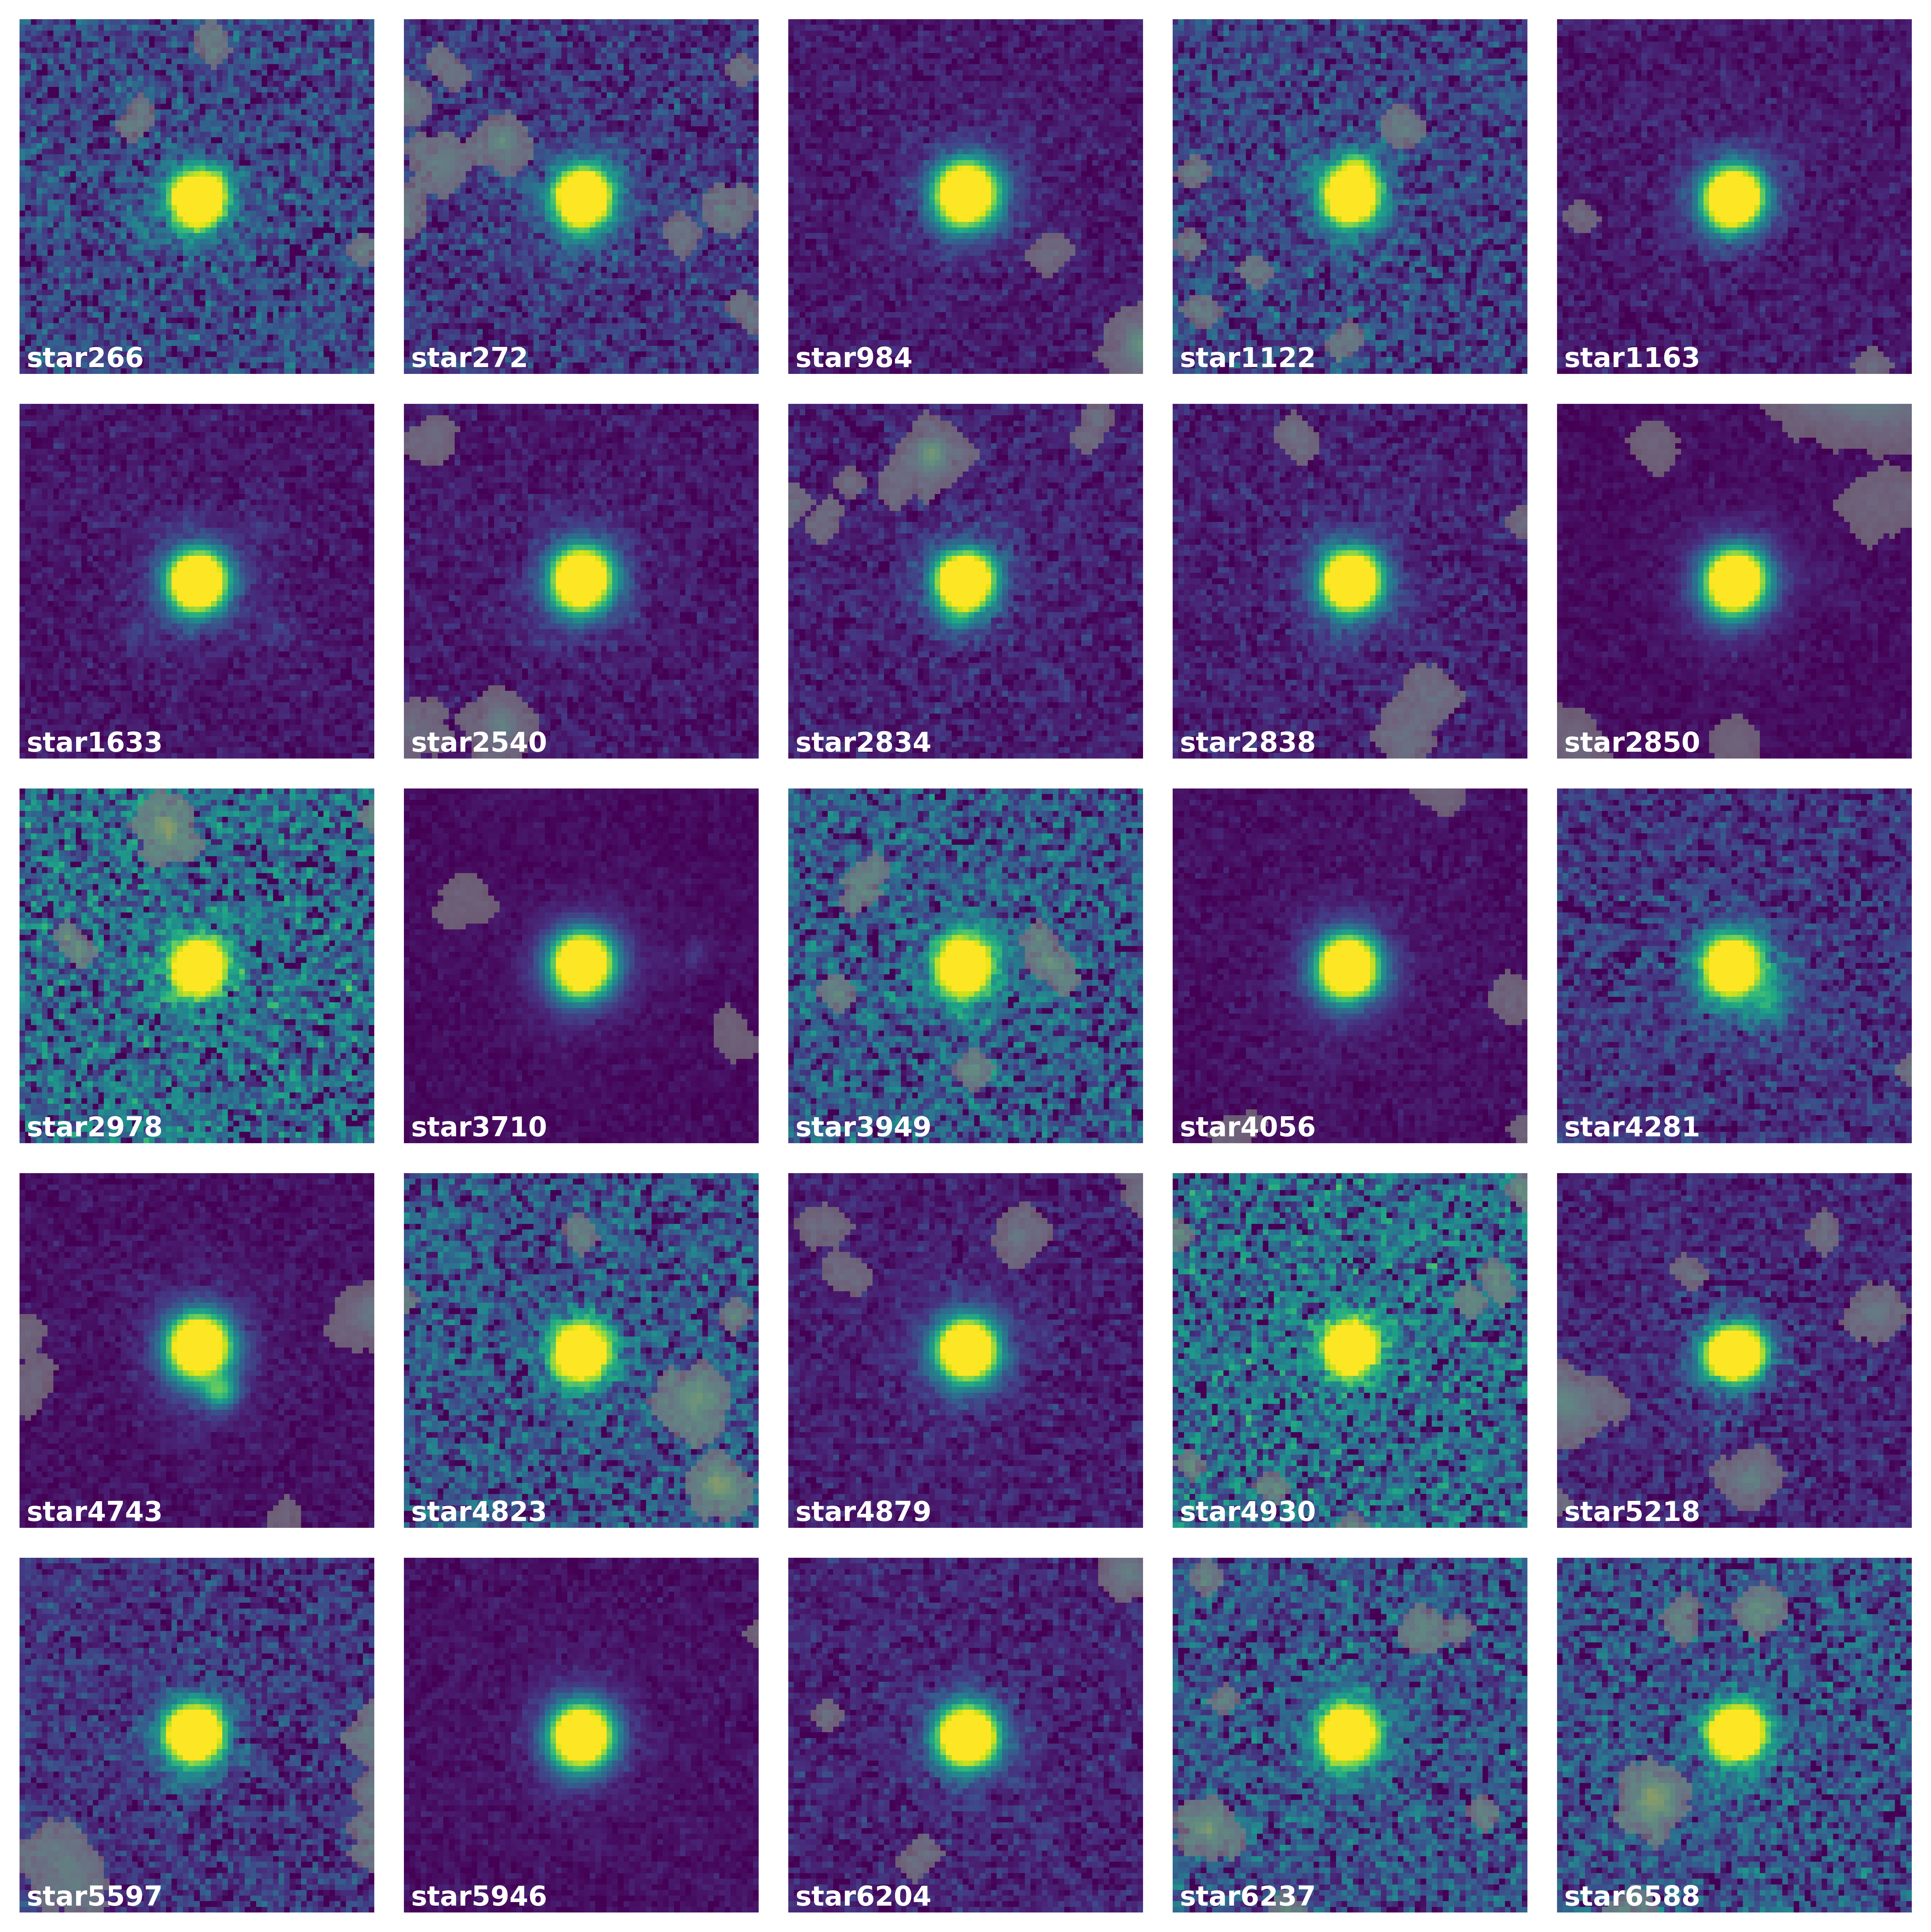

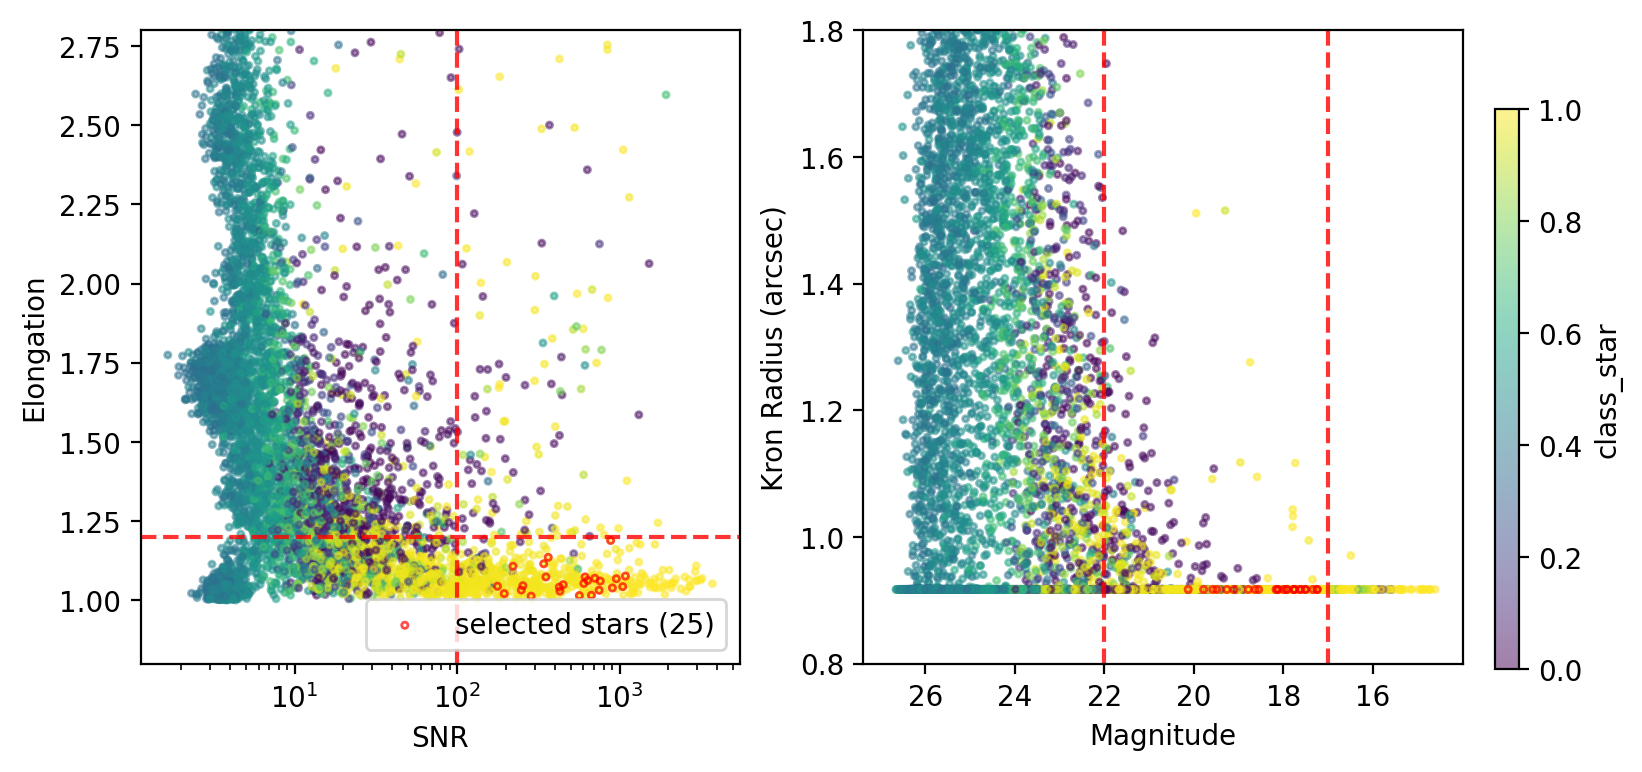

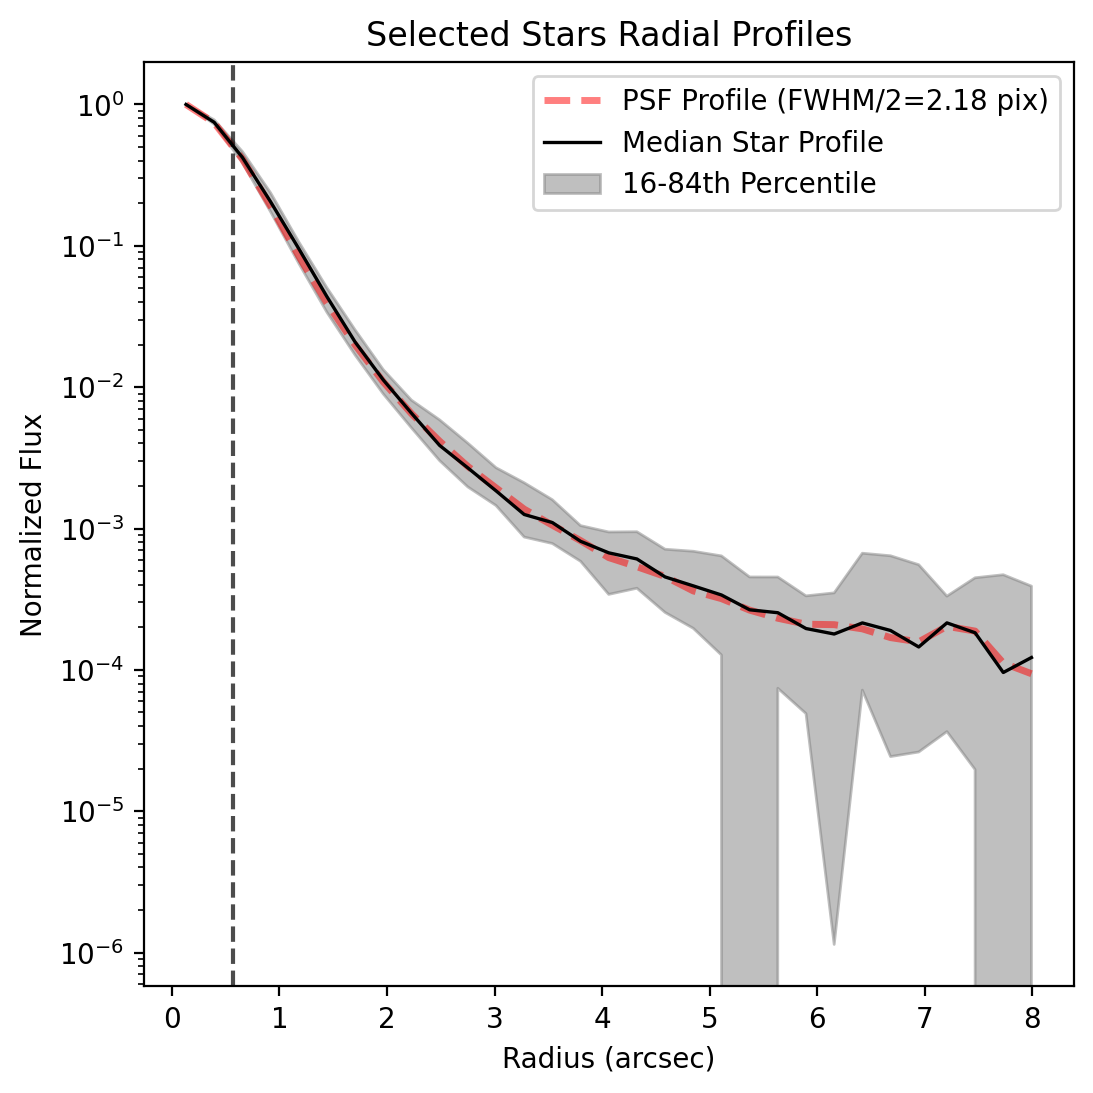

In [10]:
display(Image(os.path.join(GAIA_OUT,"selected_stars_image.png")))
display(Image(os.path.join(GAIA_OUT,"stars_scatter.png")))
display(Image(os.path.join(GAIA_OUT,"stars_radial_profiles.png")))

## Step 11: Compare Both PSFs

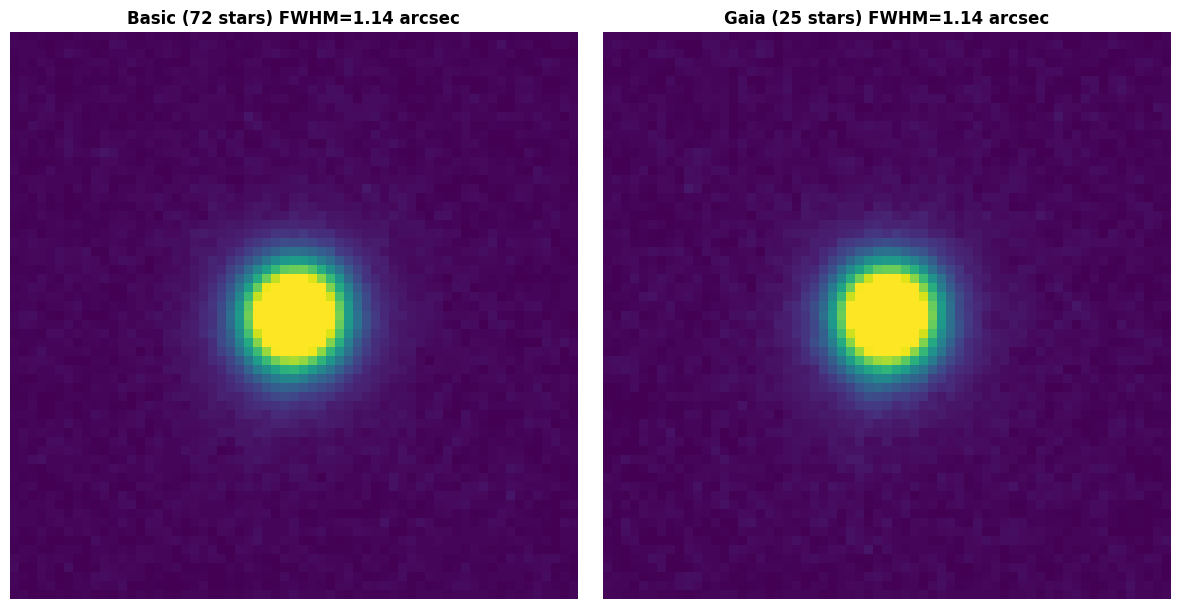

In [11]:
from photutils.psf import fit_fwhm
psf_b = fits.getdata(psf_basic)
psf_g = fits.getdata(psf_gaia)
fig,axes = plt.subplots(1,2,figsize=(12,6))
for ax,psf,title,nstar in [(axes[0],psf_b,f"Basic ({len(valid_ids)} stars)",len(valid_ids)),(axes[1],psf_g,f"Gaia ({len(valid_ids_gaia)} stars)",len(valid_ids_gaia))]:
    fwhm = fit_fwhm(psf)[0] * 0.262
    norm = simple_norm(psf,"asinh",vmin=np.percentile(psf,5),vmax=np.percentile(psf,98.5))
    ax.imshow(psf,origin="lower",cmap="viridis",norm=norm)
    ax.set_title(f"{title} FWHM={fwhm:.2f} arcsec",fontsize=12,fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 12: Exclude Bad Stars
Note that the star 1122, 2834, 4281, 4743 do not satisfy our criteria well, so we exclude them and re-do the pipeline.

In [ ]:
exclude_ids = np.array([1122, 2834, 4281, 4743])
FINAL_OUT = os.path.join(OUTPUT_DIR,"final_results")
os.makedirs(FINAL_OUT,exist_ok=True)
psf_final = build_stacked_psf(sci_image=SCI_SUB_IMAGE,
                             catalog_file=CATALOG_FILE,
                             seg_file=SEG_FILE,
                             output_dir=FINAL_OUT,
                             elongation_limit=ELONG_LIMIT,
                             class_star_limit=CLASS_STAR_LIMIT,
                             combined_flags_limit=COMBINED_FLAGS_LIMIT,
                             mag_bright_limit=MAG_BRIGHT,
                             mag_faint_limit=MAG_FAINT,
                             SNR_limit=SNR_LIMIT,
                             cutout_size=63,
                             oversampling=3,
                             select_ids=valid_ids_gaia,
                             exclude_ids=exclude_ids,       #Here we input the exclude ids.
                             pixel_scale=0.262,
                             plot_stars_image=True,
                             plot_stars_scatter=True,
                             plot_stars_radial_profile=True,
                             plot_psf_image=True,
                             psf_output_name="psf_final.fits")
print(f"Final PSF: {psf_final}")

## Step 13: Final Results

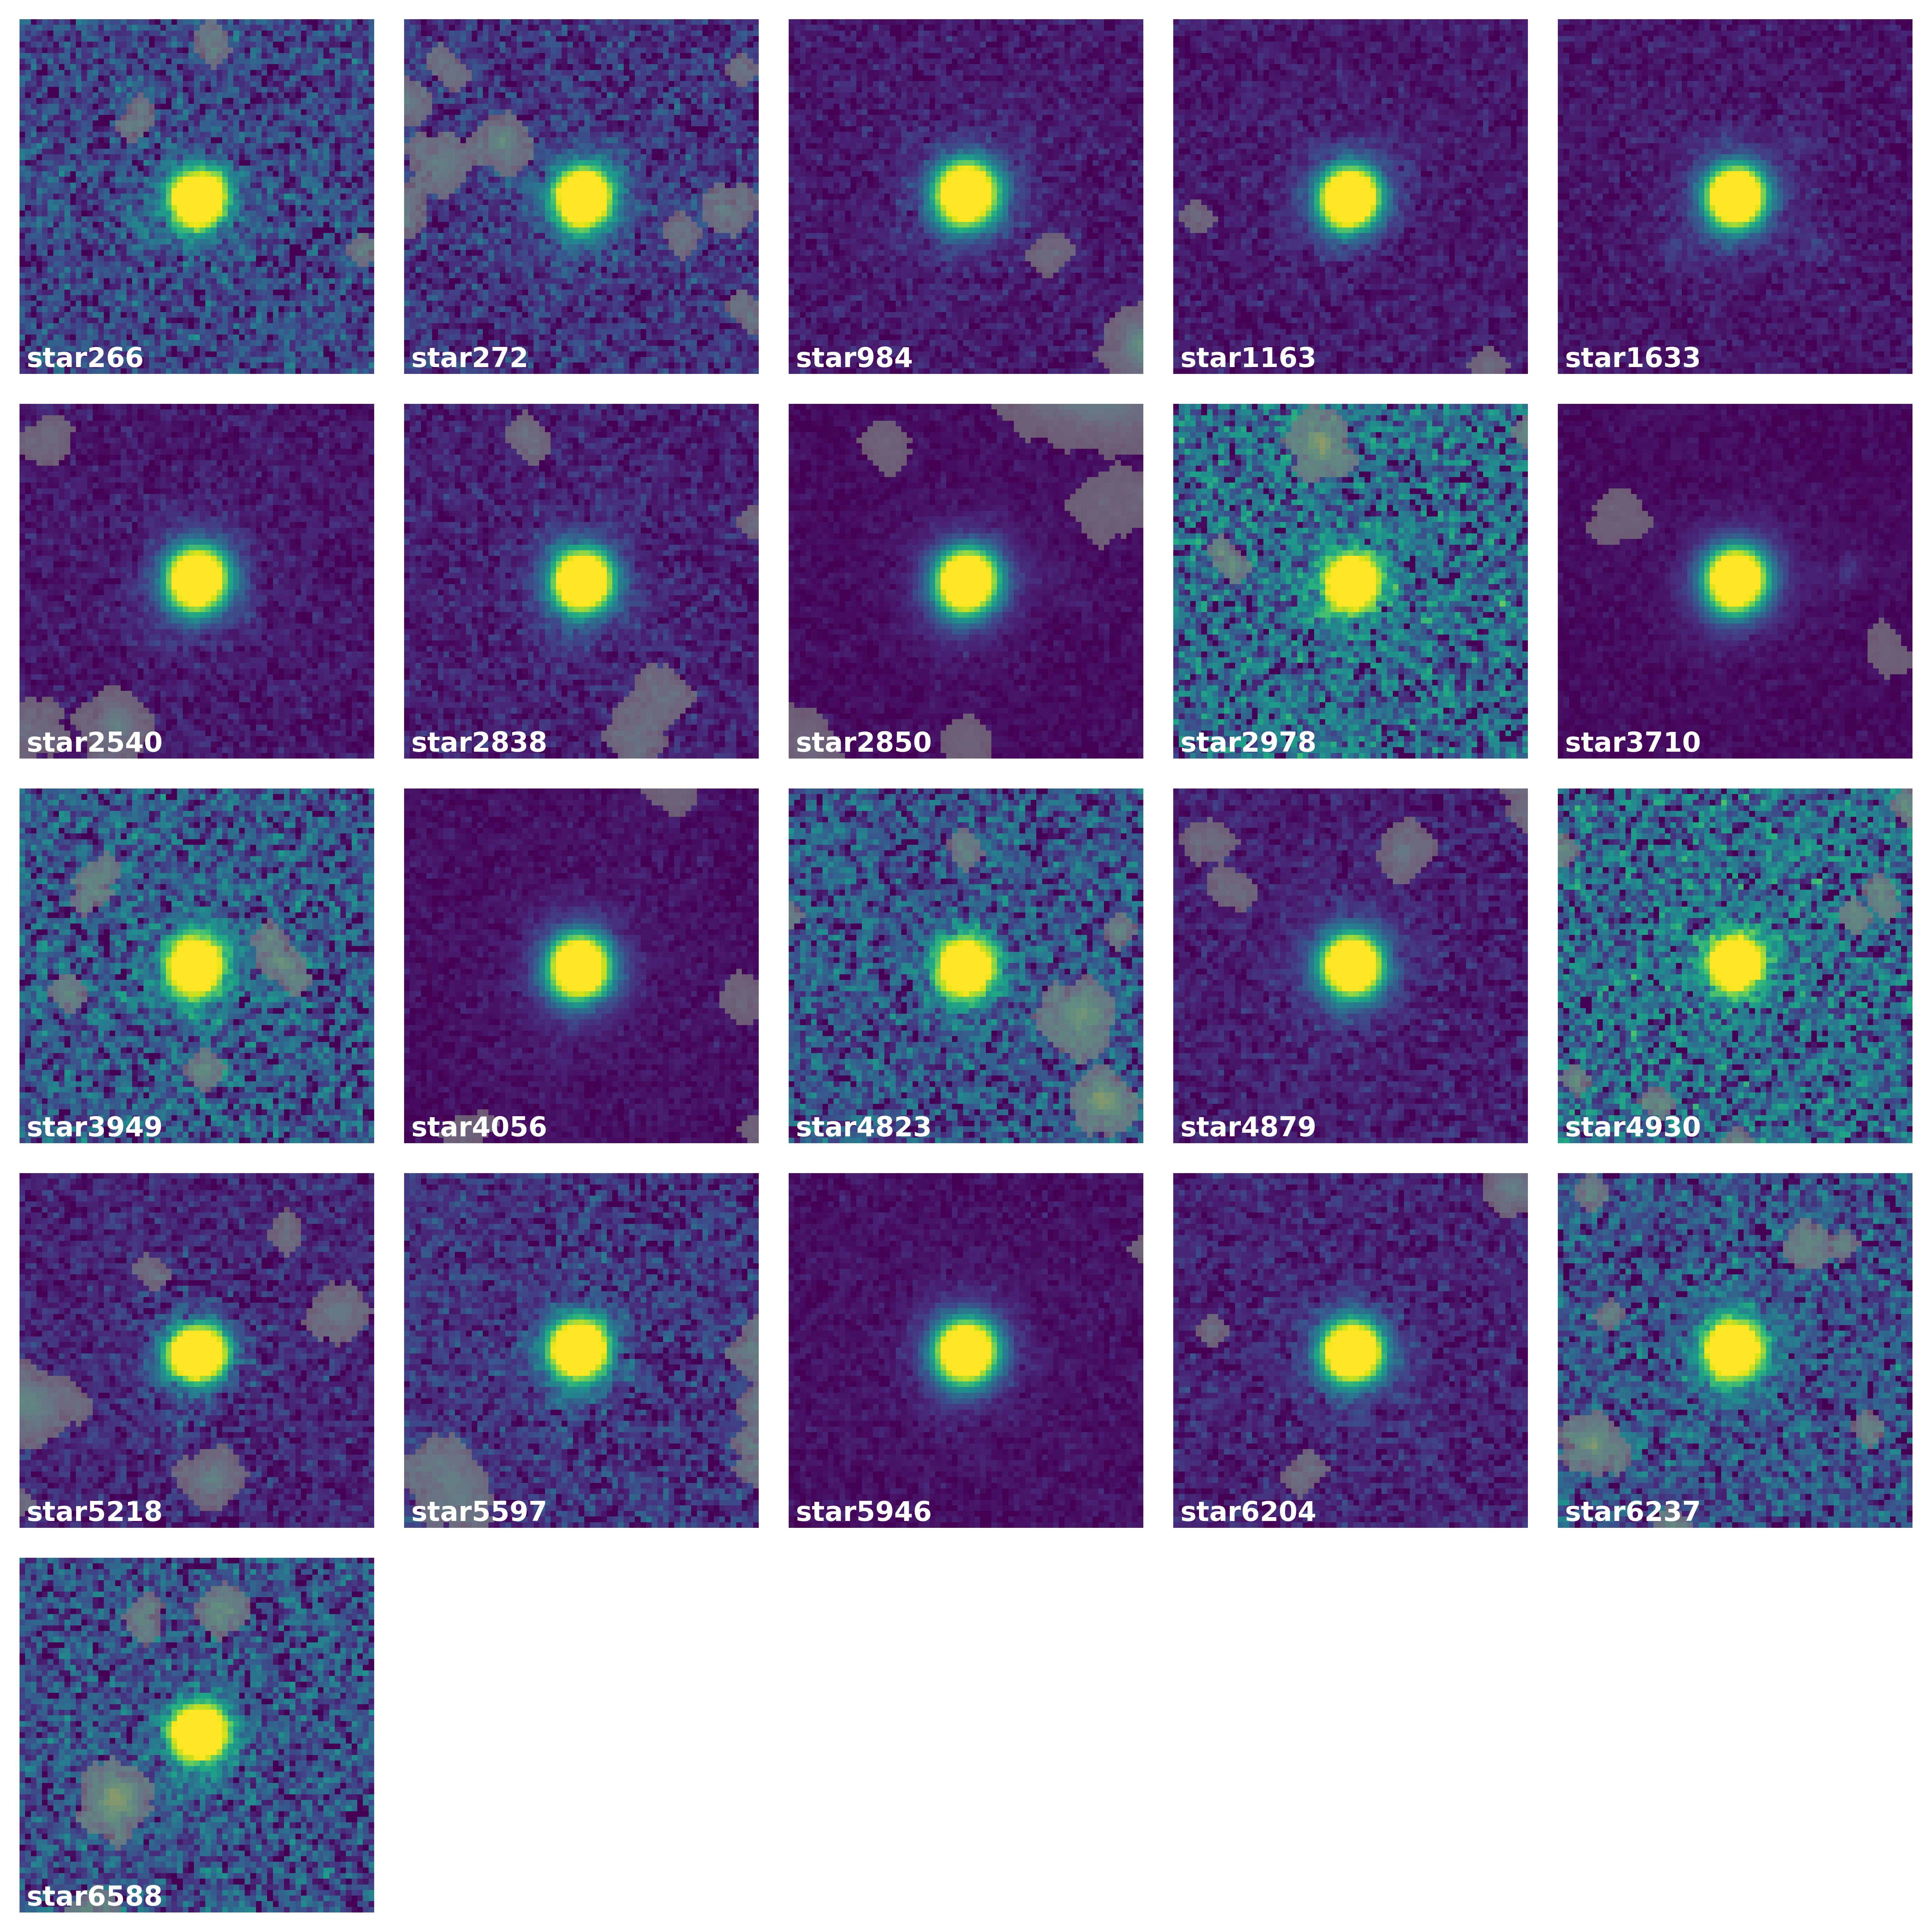

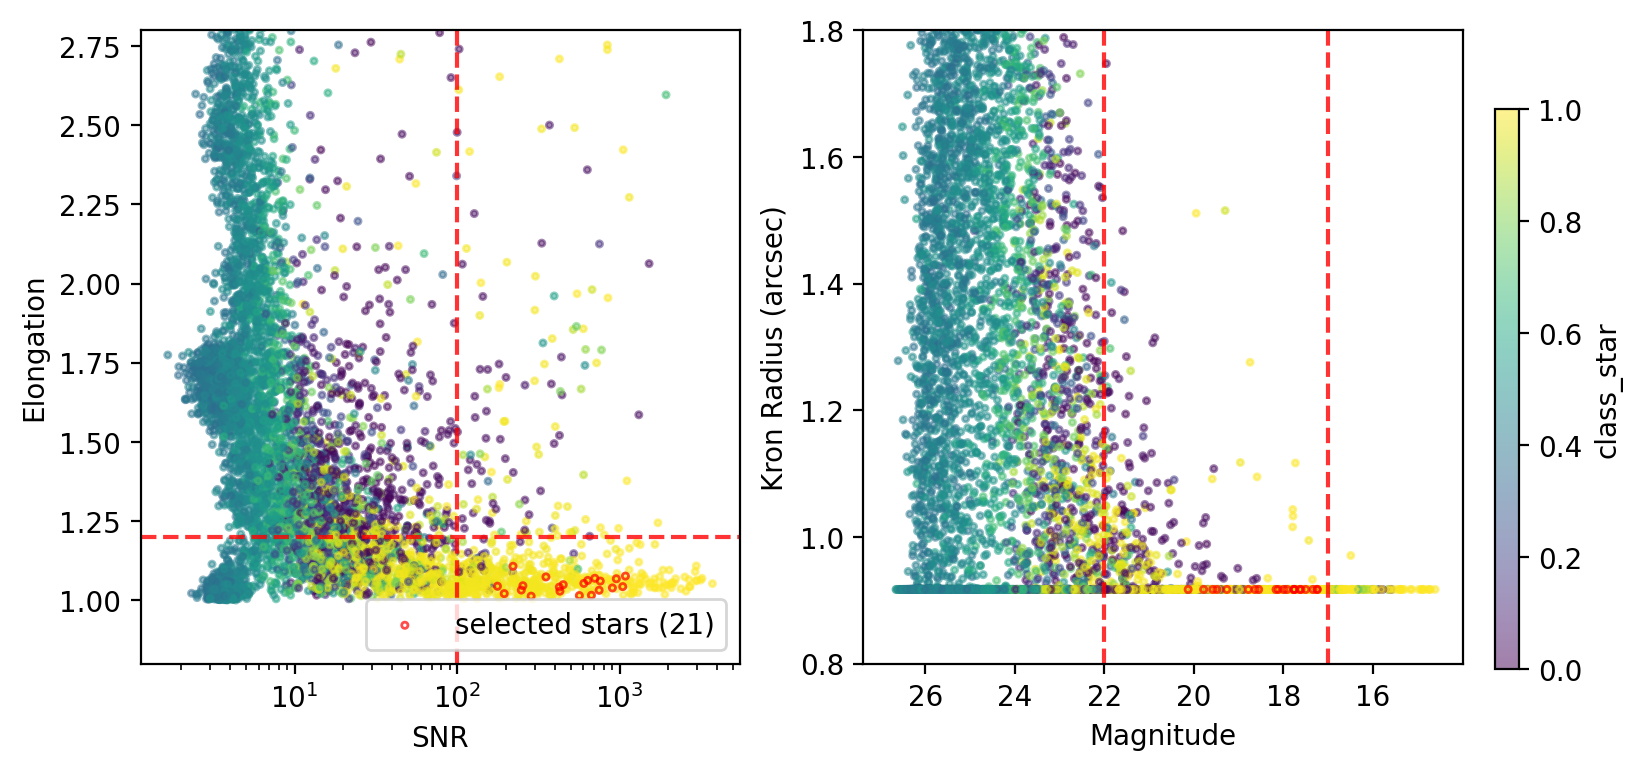

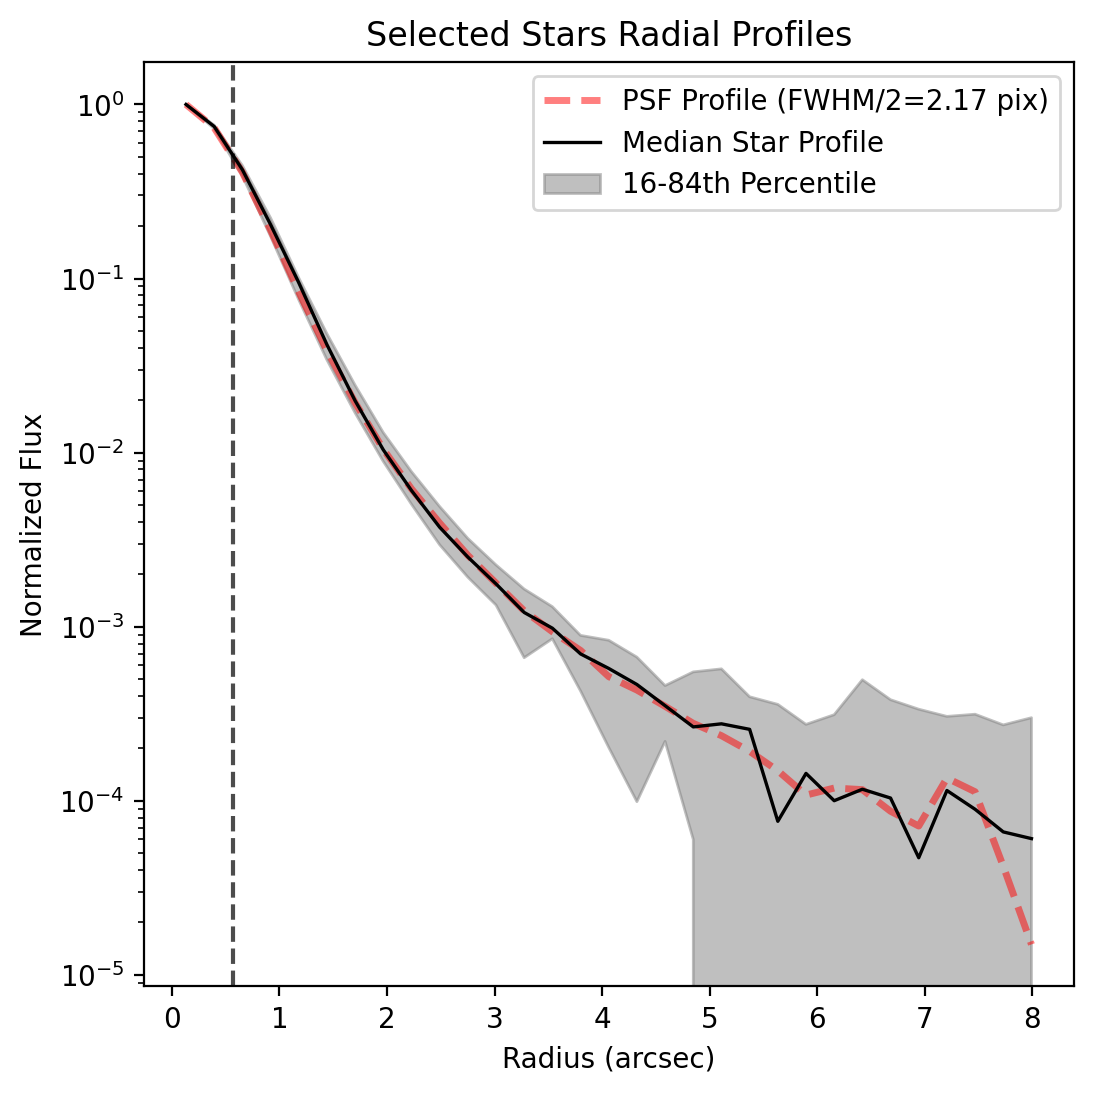

In [13]:
display(Image(os.path.join(FINAL_OUT,"selected_stars_image.png")))
display(Image(os.path.join(FINAL_OUT,"stars_scatter.png")))
display(Image(os.path.join(FINAL_OUT,"stars_radial_profiles.png")))

## Step 14: PSFs Comparison

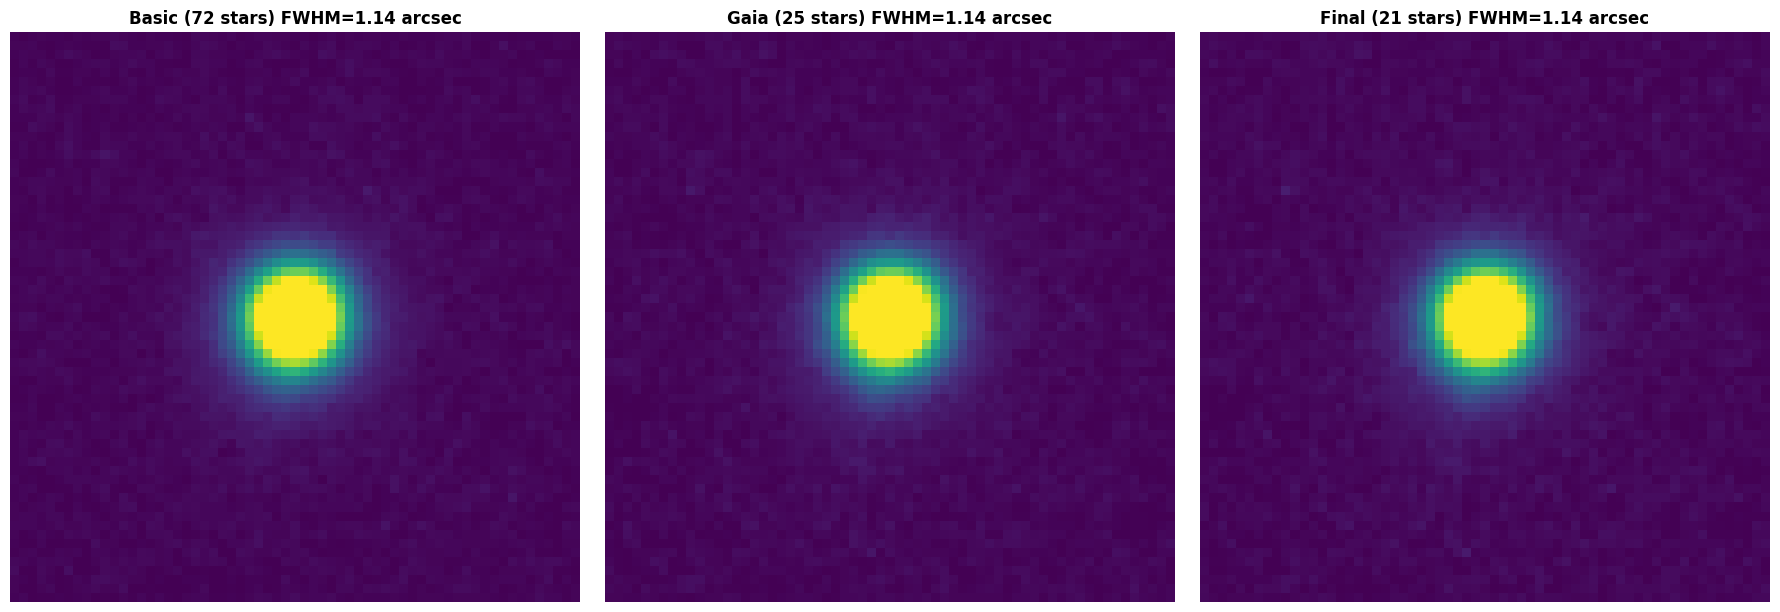

In [15]:
psf_b = fits.getdata(psf_basic)
psf_g = fits.getdata(psf_gaia)
psf_f = fits.getdata(psf_final)
fig,axes = plt.subplots(1, 3, figsize=(18,6))
for ax,psf,title,nstar in [(axes[0],psf_b,f"Basic ({len(valid_ids)} stars)",len(valid_ids)),
                           (axes[1],psf_g,f"Gaia ({len(valid_ids_gaia)} stars)",len(valid_ids_gaia)),
                           (axes[2],psf_f,f"Final ({len(valid_ids_gaia) - len(exclude_ids)} stars)",len(valid_ids_gaia) - len(exclude_ids))]:
    fwhm = fit_fwhm(psf)[0] * 0.262
    norm = simple_norm(psf,"asinh",vmin=np.percentile(psf,5),vmax=np.percentile(psf,98.5))
    ax.imshow(psf,origin="lower",cmap="viridis",norm=norm)
    ax.set_title(f"{title} FWHM={fwhm:.2f} arcsec",fontsize=12,fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()